In [1]:
%load_ext autoreload
%autoreload 2

In [3]:
from fibremodes.utilities.overlaps import overlaps
from fibremodes.analytical.LG.ModesGen import LGmodes
from fibremodes.analytical.HG.fibremodes import makeHGModes
from visualization import complexToRGB

In [5]:
from pylab import *
from PIL import Image


In [6]:
w0 = 19
px = 1
m = 22
N = 256

In [7]:
LGbases = LGmodes(w0*2,m,N,px, generateModes = True, wholeSet= True, engine='GPU', multicore=True)
HGbases = makeHGModes(N,w0,m)

Generating modes coeficients...
Generating modes...
Engine : GPU
Mem. avaliable  14.6240234375  mem. needed  0.14179687500000002  in Gb
Generating rest of the modes...


In [8]:
mm_gra = LGbases.LGmodesArray__
print(mm_gra.shape)
LG2D = reshape(mm_gra,(mm_gra.shape[0],-1)) #2D LG to use for overlaps
LG2D = transpose((LG2D))
LG2D.shape

(253, 256, 256)


(65536, 253)

# Smiley Face

In [9]:
pic = Image.open('.\data_testing\\targets\smiley_face.png')
pattern = array(pic)[...,0]

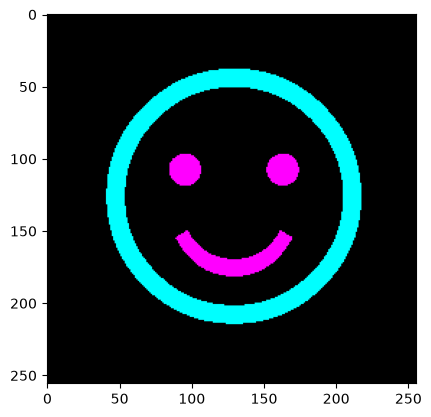

In [10]:
patternSmily = zeros((256,256),complex64)
(patternSmily)[ (pattern/255) < 0.5] = 1
(patternSmily)[ (pattern/255) >= 0.5] = 0

x = linspace(-N//2,N//2,N)
X, Y = meshgrid(x,x)

R = sqrt(X**2 + Y**2)

r = 55
adjust_phase_pattern = zeros_like(pattern).astype(float)
adjust_phase_pattern[R<r] = -1

patternSmily = abs(patternSmily) * exp(1j*np.angle(adjust_phase_pattern))

imshow(complexToRGB(patternSmily))

In [11]:
smiley_coefs = overlaps.Modal_decomposition(LG2D, patternSmily)

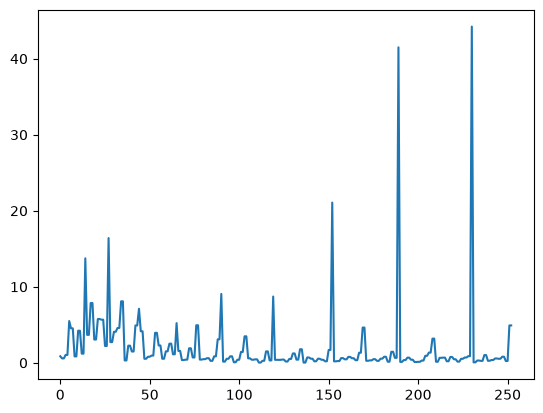

In [12]:
plot(abs(smiley_coefs)[0])

# Sad face

In [16]:
pic = Image.open('.\data_testing\\targets\sad_face.png')
pic = pic.resize((256,256))
pattern = array(pic)[...,0]

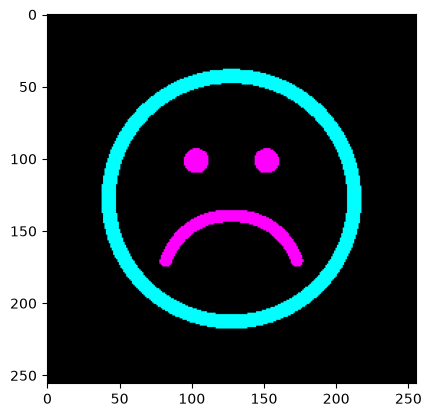

In [19]:
patternSad = zeros((256,256),complex64)
(patternSad)[ (pattern/255) < 0.5] = 1
(patternSad)[ (pattern/255) >= 0.5] = 0

r = 70
adjust_phase_pattern = zeros_like(pattern).astype(float)
adjust_phase_pattern[R<r] = -1
patternSad = abs(patternSad) * exp(1j*np.angle(adjust_phase_pattern))

imshow(complexToRGB(patternSad))

In [20]:
sad_coefs = overlaps.Modal_decomposition(LG2D, patternSad)

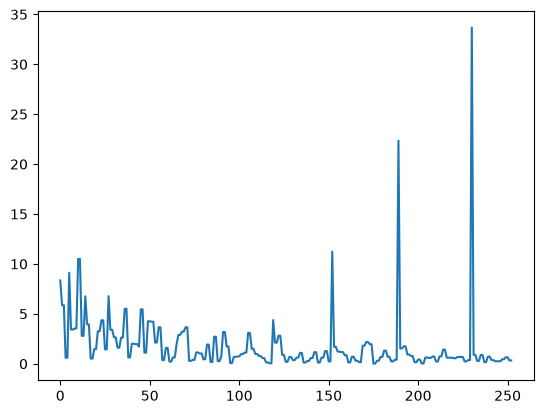

In [21]:
plot(abs(sad_coefs)[0])

In [39]:
smiley_reconstructed = overlaps.Modal_reconstruction(conjugate(LG2D), smiley_coefs)
sad_reconstructed = overlaps.Modal_reconstruction(conjugate(LG2D), sad_coefs)

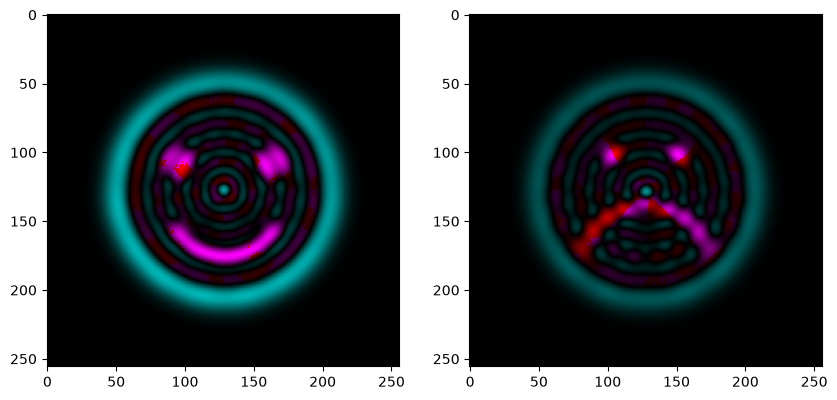

In [41]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(complexToRGB(smiley_reconstructed[0,...]))
axs[1].imshow(complexToRGB(sad_reconstructed[0,...]))



In [45]:
faces = {'smiley': smiley_coefs, 'sad': sad_coefs, 'mode group': m, 'basis': 'LG'}

In [47]:
np.savez('.\data_testing\\modal_decompositions\\faces.npz', **faces)